# 1D Column-Wise Gaussian Mixture Models (GMM)
Instead of fitting a global curve using nonlinear least squares, this approach fits a 1D Gaussian Mixture Model to each 'Week of Year' bin to establish the local modes (peaks) in density. 
* **SST**: n_components = 2 
* **SSL**: n_components = 3

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import warnings
from tqdm.auto import tqdm

plt.style.use('default')

In [2]:
# 1. Load the data
file_path = r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl'
try:
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    df = data['data']
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Data file not found. Please check path.")

# Extract just SST and SSL
df_all_years = df.copy()
df_all_years['week'] = df_all_years.index.isocalendar().week

products = ['sst', 'ssl']
weekly_data = {p: [] for p in products}

for week_num, week_df in tqdm(df_all_years.groupby('week'), desc="Processing weeks"):
    for p in products:
        grids = []
        for _, row in week_df.iterrows():
            grid = row.get(p)
            if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
                grid_arr = np.array(grid, dtype=float)
                if not np.isnan(grid_arr).all():
                    grids.append(grid_arr)
        
        if grids:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', category=RuntimeWarning)
                avg_grid = np.nanmean(np.stack(grids), axis=0)
                values = avg_grid.flatten()
                values = values[~np.isnan(values)]
                
                if len(values) > 0:
                    for val in values:
                        weekly_data[p].append({'week': week_num, 'value': val})

for p in products:
    weekly_data[p] = pd.DataFrame(weekly_data[p])

Data loaded successfully.


Processing weeks:   0%|          | 0/53 [00:00<?, ?it/s]

In [3]:
# Function to create the density map (2D Histogram) for background plotting
def get_density_map(df_p, y_bins_count=100):
    x_bins = np.arange(1, 54) - 0.5
    range_y = [df_p['value'].min(), df_p['value'].max()]
    
    h, xedges, yedges = np.histogram2d(
        df_p['week'], df_p['value'],
        bins=[x_bins, y_bins_count],
        range=[[0.5, 52.5], range_y]
    )
    
    # Store bin centers for plotting/fitting
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    
    return h, x_centers, y_centers

## SST: 1D Column-Wise GMM (2 Components)

In [4]:
df_sst = weekly_data['sst']
h_sst, x_sst, y_sst = get_density_map(df_sst, y_bins_count=100)

weeks = sorted(df_sst['week'].unique())
sst_means = {1: [], 2: []}

# Fit a 1D GMM for each week individually
for w in weeks:
    week_vals = df_sst[df_sst['week'] == w]['value'].values.reshape(-1, 1)
    if len(week_vals) > 10:  # Need enough points to fit GMM reliably
        gmm = GaussianMixture(n_components=2, random_state=42)
        gmm.fit(week_vals)
        
        # Sort means to consistently track the 'top' and 'bottom' curve
        means = np.sort(gmm.means_.flatten())
        sst_means[1].append((w, means[0]))  # Bottom curve
        sst_means[2].append((w, means[1]))  # Top curve

# Convert to arrays for plotting
sst_c1 = np.array(sst_means[1])
sst_c2 = np.array(sst_means[2])

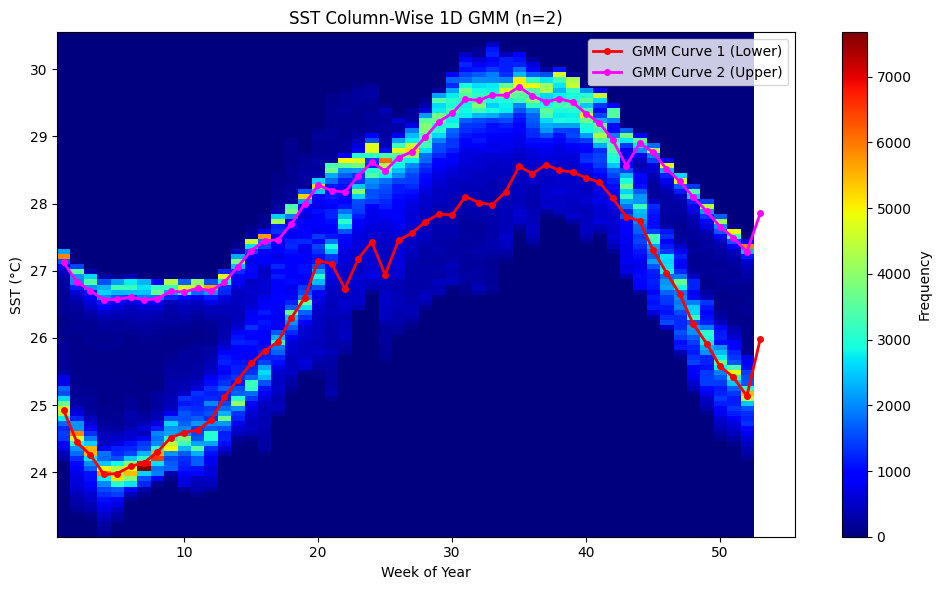

In [5]:
# Plot SST Results
plt.figure(figsize=(10, 6))

plt.imshow(h_sst.T, origin='lower', aspect='auto', 
           extent=[0.5, 52.5, y_sst.min(), y_sst.max()], 
           cmap='jet')
plt.colorbar(label='Frequency')

plt.plot(sst_c1[:, 0], sst_c1[:, 1], color='red', lw=2, marker='o', markersize=4, label='GMM Curve 1 (Lower)')
plt.plot(sst_c2[:, 0], sst_c2[:, 1], color='magenta', lw=2, marker='o', markersize=4, label='GMM Curve 2 (Upper)')

plt.title("SST Column-Wise 1D GMM (n=2)")
plt.xlabel("Week of Year")
plt.ylabel("SST (°C)")
plt.legend()
plt.tight_layout()
plt.show()

## SSL: 1D Column-Wise GMM (3 Components)

In [6]:
df_ssl = weekly_data['ssl']
h_ssl, x_ssl, y_ssl = get_density_map(df_ssl, y_bins_count=150)

weeks_ssl = sorted(df_ssl['week'].unique())
ssl_means = {1: [], 2: [], 3: []}

for w in weeks_ssl:
    week_vals = df_ssl[df_ssl['week'] == w]['value'].values.reshape(-1, 1)
    if len(week_vals) > 10:
        gmm = GaussianMixture(n_components=3, random_state=42)
        gmm.fit(week_vals)
        
        # Sort means to consistently track the 'bottom', 'middle' and 'top' curve
        means = np.sort(gmm.means_.flatten())
        ssl_means[1].append((w, means[0]))
        ssl_means[2].append((w, means[1]))
        ssl_means[3].append((w, means[2]))

ssl_c1 = np.array(ssl_means[1])
ssl_c2 = np.array(ssl_means[2])
ssl_c3 = np.array(ssl_means[3])

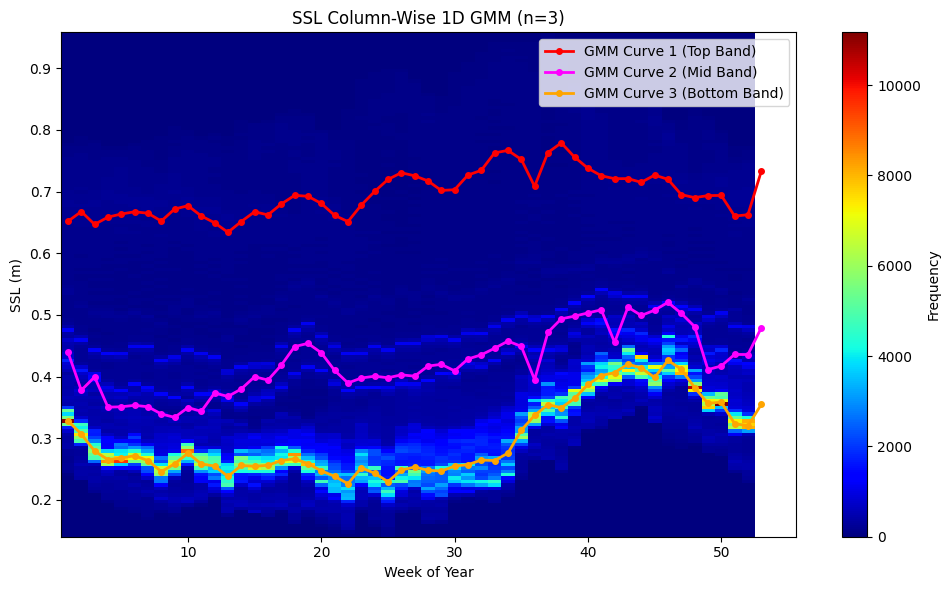

In [7]:
# Plot SSL Results
plt.figure(figsize=(10, 6))

plt.imshow(h_ssl.T, origin='lower', aspect='auto', 
           extent=[0.5, 52.5, y_ssl.min(), y_ssl.max()], 
           cmap='jet')
plt.colorbar(label='Frequency')

plt.plot(ssl_c3[:, 0], ssl_c3[:, 1], color='red', lw=2, marker='o', markersize=4, label='GMM Curve 1 (Top Band)')
plt.plot(ssl_c2[:, 0], ssl_c2[:, 1], color='magenta', lw=2, marker='o', markersize=4, label='GMM Curve 2 (Mid Band)')
plt.plot(ssl_c1[:, 0], ssl_c1[:, 1], color='orange', lw=2, marker='o', markersize=4, label='GMM Curve 3 (Bottom Band)')

plt.title("SSL Column-Wise 1D GMM (n=3)")
plt.xlabel("Week of Year")
plt.ylabel("SSL (m)")
plt.legend()
plt.tight_layout()
plt.show()